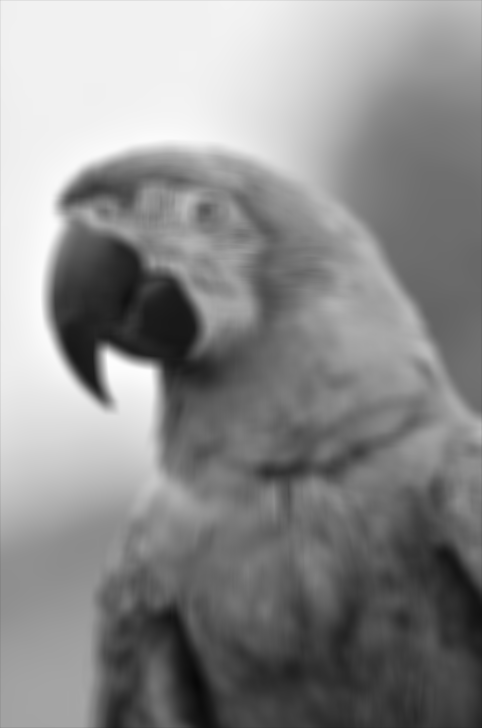

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def filtering(img, kernel, p, s):
    m, n = img.shape
    x, y = kernel.shape

    rows = (m - x + 2 * p) // s + 1
    cols = (n - y + 2 * p) // s + 1

    padded_img = np.pad(img, p, constant_values=0)

    output = np.zeros((rows, cols))

    for i in range(rows):
        for j in range(cols):
            output[i][j] = np.sum(
                padded_img[i*s:i*s+x, j*s:j*s+y] * kernel
            )

    return output



k = 15
p = 1
s = 1

img = cv2.imread("/content/drive/MyDrive/parrot.jpg", 0)

kernel = np.ones((k, k)) / k**2

filtered_output = filtering(img, kernel, p, s)

cv2_imshow(filtered_output.astype(np.uint8))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


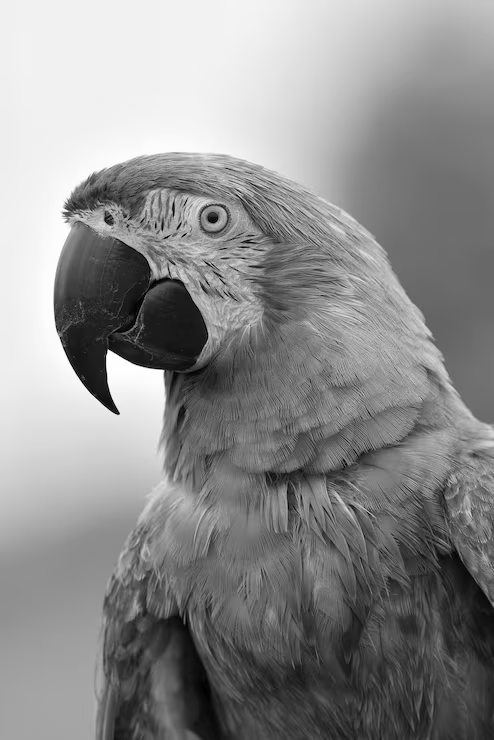

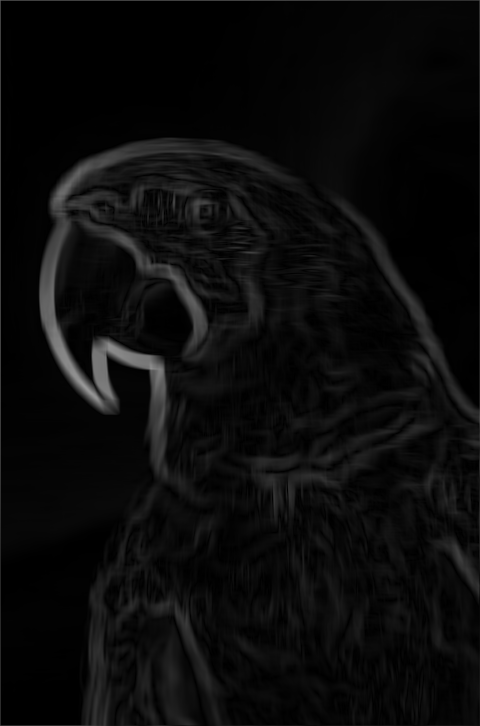

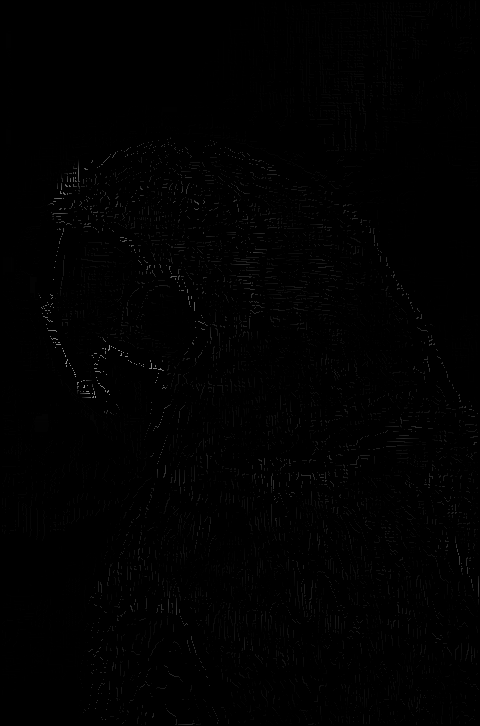

In [ ]:



sobel_kernel_x = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

sobel_kernel_y = sobel_kernel_x.T


filtered_image_x = filtering(
    filtered_output, sobel_kernel_x, p=0, s=1
)

filtered_image_y = filtering(
    filtered_output, sobel_kernel_y, p=0, s=1
)


mag_filtered_img = np.sqrt(
    filtered_image_x**2 + filtered_image_y**2
)


angle_filtered_img = np.degrees(
    np.arctan2(filtered_image_y, filtered_image_x)
)


angle_filtered_img[angle_filtered_img < 0] += 180



angle_quantized = np.zeros_like(angle_filtered_img)

for i in range(angle_filtered_img.shape[0]):
    for j in range(angle_filtered_img.shape[1]):

        angle = angle_filtered_img[i, j]

        if (-22.5 <= angle < 22.5) or (157.5 <= angle <= 180):
            angle_quantized[i, j] = 0

        elif 22.5 <= angle < 67.5:
            angle_quantized[i, j] = 45

        elif 67.5 <= angle < 112.5:
            angle_quantized[i, j] = 90

        elif 112.5 <= angle < 157.5:
            angle_quantized[i, j] = 135



nms = np.zeros_like(mag_filtered_img)

rows, cols = mag_filtered_img.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):

        angle = angle_quantized[i, j]

        # 0 degree
        if angle == 0:
            p1 = mag_filtered_img[i, j-1]
            p2 = mag_filtered_img[i, j+1]

        # 45 degree
        elif angle == 45:
            p1 = mag_filtered_img[i-1, j+1]
            p2 = mag_filtered_img[i+1, j-1]

        # 90 degree
        elif angle == 90:
            p1 = mag_filtered_img[i-1, j]
            p2 = mag_filtered_img[i+1, j]

        # 135 degree
        else:
            p1 = mag_filtered_img[i-1, j-1]
            p2 = mag_filtered_img[i+1, j+1]

        if mag_filtered_img[i, j] >= p1 and \
           mag_filtered_img[i, j] >= p2:

            nms[i, j] = mag_filtered_img[i, j]

        else:
            nms[i, j] = 0


# ---------- Display ----------
cv2_imshow(img) # Display original image
cv2_imshow(mag_filtered_img.astype(np.uint8)) # Display gradient magnitude
cv2_imshow(nms.astype(np.uint8)) # Display NMS output


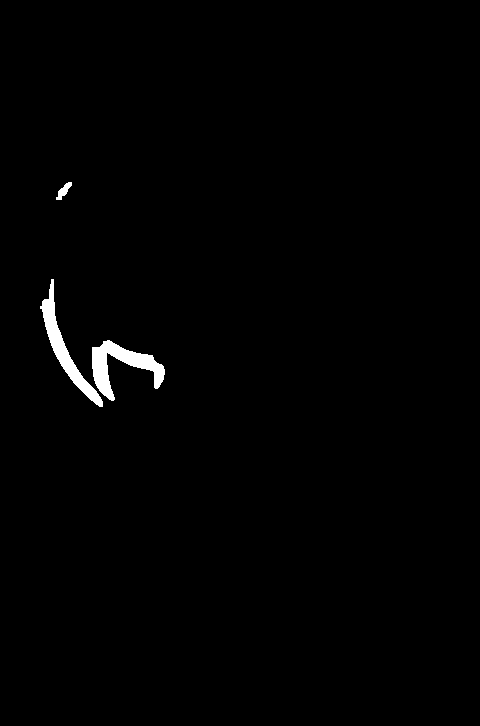

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow



T_low = 50
T_high = 100

strong_edge = mag_filtered_img > T_high

weak_edge = (
    (mag_filtered_img >= T_low) &
    (mag_filtered_img <= T_high)
)




whole_edge = strong_edge.copy()

for i in range(1, weak_edge.shape[0] - 1):
    for j in range(1, weak_edge.shape[1] - 1):

        if weak_edge[i][j]:


            neighbors = [
                strong_edge[i-1][j-1],
                strong_edge[i-1][j],
                strong_edge[i-1][j+1],
                strong_edge[i][j-1],
                strong_edge[i][j+1],
                strong_edge[i+1][j-1],
                strong_edge[i+1][j],
                strong_edge[i+1][j+1]
            ]


            if any(neighbors):
                whole_edge[i][j] = True



canny_edge = whole_edge.astype(np.uint8) * 255

cv2_imshow(canny_edge)
